# Analysis of Traffic Patterns on Gamedays vs Non-Gamedays

Intention is to create some map visualizations that compares traffic patterns on gamedays vs nongamedays.

So perhaps limiting the dataset just to one of the radius regions 

Well actualyl no maybe not the maps, more so maybe some boxplots of baseline vs gameday arrest rates, number stops, etc.

In [1]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import folium
from folium.plugins import HeatMap
import seaborn as sns
import matplotlib.pyplot as plt

### Boxplots comparing the number of arrests & stops on non-gamedays vs gamedays

In [2]:
philly_stops = pd.read_csv("/home/jasmine/PROJECTS/sds357-project-sp26-i-love-philly/data/DATA_WITH_DISTANCES_KM.csv")
philly_stops

/tmp/ipykernel_48651/2969800158.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  philly_stops = pd.read_csv("/home/jasmine/PROJECTS/sds357-project-sp26-i-love-philly/data/DATA_WITH_DISTANCES_KM.csv")


,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,flyers_home_game,flyers_away_game,distance_from_eagles,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,False,False,6.689936,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,False,False,3.648924,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,False,False,6.913681,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,False,False,3.424703,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,False,False,6.693603,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211


In [3]:
philly_stops.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband',
       'eagles_home_game', 'eagles_away_game', '76ers_home_game',
       '76ers_away_game', 'phillies_home_game', 'phillies_away_game',
       'flyers_home_game', 'flyers_away_game', 'distance_from_eagles',
       'distance_from_76ers', 'distance_from_phillies', 'distance_from_flyers',
       'distance_from_eagles_km', 'distance_from_76ers_km',
       'distance_from_phillies_km', 'distance_from_flyers_km'],
      dtype='object')

In [4]:
eagles = pd.read_csv("../data/cleanedEaglesData.csv")
eagles

,Game,Day,Date,StartTime,xEndTime,Home,Opp,TeamScore,OppScore,PointDiff,...,Wins,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl
0,1,Sunday,2014-09-07,13:02:00,16:14:00,0,Jacksonville Jaguars,34,17,17,...,1,0,1,0,0,0,1,0,0,0
1,2,Monday,2014-09-15,20:31:00,23:43:00,1,Indianapolis Colts,30,27,3,...,2,0,2,0,0,0,1,0,0,0
2,3,Sunday,2014-09-21,13:02:00,16:14:00,0,Washington Redskins,37,34,3,...,3,0,3,0,0,0,1,0,0,0
3,4,Sunday,2014-09-28,16:25:00,19:37:00,1,San Francisco 49ers,21,26,-5,...,3,1,-1,0,0,0,1,0,0,0
4,5,Sunday,2014-10-05,13:02:00,16:14:00,0,St. Louis Rams,34,28,6,...,4,1,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,16,Monday,2017-12-25,20:30:00,23:42:00,0,Oakland Raiders,19,10,9,...,13,2,3,0,0,0,1,0,0,0
63,17,Sunday,2017-12-31,13:00:00,16:12:00,0,Dallas Cowboys,0,6,-6,...,13,3,-1,1,0,1,1,0,0,0
64,Division,Saturday,2018-01-13,16:35:00,19:47:00,0,Atlanta Falcons,15,10,5,...,14,3,1,0,0,0,0,1,0,0
65,Conf. Champ.,Sunday,2018-01-21,18:40:00,21:52:00,0,Minnesota Vikings,38,7,31,...,15,3,2,0,0,0,0,0,1,0


In [5]:
philly_stops['date'] = pd.to_datetime(philly_stops['date'], format='mixed', errors='coerce').dt.date

In [6]:
eagles['Date'] = pd.to_datetime(eagles['Date']).dt.date

In [7]:
philly_stops = philly_stops.dropna(subset=['date'])

In [8]:
philly_stops = philly_stops.dropna(subset=["date", "time", "lat", "lng"])
philly_stops

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,flyers_home_game,flyers_away_game,distance_from_eagles,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,False,False,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,False,False,6.689936,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,False,False,3.648924,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,False,False,6.913681,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,False,False,3.424703,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,False,False,6.693603,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,False,False,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211


In [9]:
import numpy as np

# Stadium coordinates
stadium_lat = 39.9014
stadium_lng = -75.1676

# Convert to radians
lat1 = np.radians(philly_stops['lat'])
lon1 = np.radians(philly_stops['lng'])
lat2 = np.radians(stadium_lat)
lon2 = np.radians(stadium_lng)

# Haversine formula
dlat = lat1 - lat2
dlon = lon1 - lon2

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius_km = 6371
philly_stops['distance_km'] = earth_radius_km * c

# Create region rings
philly_stops['region'] = np.ceil(philly_stops['distance_km']).astype('Int64')

# Set regions > 5 km to NA
philly_stops.loc[philly_stops['region'] > 5, 'region'] = pd.NA
philly_stops

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_eagles,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,distance_km,region
0,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,5.855768,<NA>
1,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,3.635238,3.569368,3.359393,3.569368,5.850334,5.744326,5.406406,5.744326,5.855768,<NA>
2,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,6.689936,6.581353,6.449271,6.581353,10.766381,10.591634,10.379070,10.591634,10.770188,<NA>
3,398805,2014-01-01,08:53:00,CHESTNUT ST / S SCHUYLKILL AV W,39.953124,-75.181936,18.0,181,38.0,black,...,3.648924,3.621048,3.346315,3.621048,5.872359,5.827497,5.385358,5.827497,5.879916,<NA>
4,231349,2014-01-01,09:00:00,N 52ND ST / GAINOR RD,39.989757,-75.229019,19.0,193,19.0,black,...,6.913681,6.818935,6.658408,6.818935,11.126464,10.973985,10.715642,10.973985,11.132890,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760038,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,3.424703,3.237925,3.313627,3.237925,5.511511,5.210922,5.332753,5.210922,5.504073,<NA>
1760039,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,6.693603,6.697400,6.373917,6.697400,10.772283,10.778393,10.257799,10.778393,10.787800,<NA>
1760040,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,15.405070,<NA>
1760041,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,9.561694,9.646322,9.234700,9.646322,15.388016,15.524211,14.861771,15.524211,15.405070,<NA>


In [10]:
# look at NAs first
philly_stops['region'].value_counts(dropna=False) # Indicates a lot more observations outside the 5 km radius

# drop region NAs (indicates far from stadium)
philly_stops.dropna(subset=['region'], inplace=True)

In [11]:
philly_stops['hour'] = pd.to_datetime(philly_stops['time'], format='%H:%M:%S').dt.hour
philly_stops.head()

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,distance_km,region,hour
203,400648,2014-01-04,20:50:00,S 18TH ST / JACKSON ST,39.923970,-75.176364,1.0,011,38.0,white,...,1.587955,1.339625,1.587955,2.615601,2.555560,2.155912,2.555560,2.618576,3,20
347,90167,2014-01-08,10:07:00,S 22ND ST / OREGON AV,39.918452,-75.184405,1.0,012,43.0,white,...,1.360550,1.277165,1.360550,2.376842,2.189588,2.055393,2.189588,2.376885,3,10
411,90168,2014-01-08,22:45:00,S 21ST ST / OREGON AV,39.918242,-75.182823,1.0,012,49.0,white,...,1.308839,1.205741,1.308839,2.278405,2.106366,1.940447,2.106366,2.278798,3,22
777,90315,2014-01-13,09:10:00,2200 BLOCK OREGON AV,39.918418,-75.184465,1.0,012,64.0,white,...,1.360076,1.277997,1.360076,2.376983,2.188825,2.056731,2.188825,2.377002,3,9
780,90316,2014-01-13,09:49:00,S 20TH ST / PORTER ST,39.920629,-75.180317,1.0,011,44.0,white,...,1.411415,1.242439,1.411415,2.395991,2.271447,1.999507,2.271447,2.397544,3,9


In [12]:
# Drop time column
philly_stops.drop(columns=['time'], inplace=True)
philly_stops.head()

,raw_row_number,date,location,lat,lng,district,service_area,subject_age,subject_race,subject_sex,...,distance_from_76ers,distance_from_phillies,distance_from_flyers,distance_from_eagles_km,distance_from_76ers_km,distance_from_phillies_km,distance_from_flyers_km,distance_km,region,hour
203,400648,2014-01-04,S 18TH ST / JACKSON ST,39.923970,-75.176364,1.0,011,38.0,white,female,...,1.587955,1.339625,1.587955,2.615601,2.555560,2.155912,2.555560,2.618576,3,20
347,90167,2014-01-08,S 22ND ST / OREGON AV,39.918452,-75.184405,1.0,012,43.0,white,female,...,1.360550,1.277165,1.360550,2.376842,2.189588,2.055393,2.189588,2.376885,3,10
411,90168,2014-01-08,S 21ST ST / OREGON AV,39.918242,-75.182823,1.0,012,49.0,white,male,...,1.308839,1.205741,1.308839,2.278405,2.106366,1.940447,2.106366,2.278798,3,22
777,90315,2014-01-13,2200 BLOCK OREGON AV,39.918418,-75.184465,1.0,012,64.0,white,male,...,1.360076,1.277997,1.360076,2.376983,2.188825,2.056731,2.188825,2.377002,3,9
780,90316,2014-01-13,S 20TH ST / PORTER ST,39.920629,-75.180317,1.0,011,44.0,white,female,...,1.411415,1.242439,1.411415,2.395991,2.271447,1.999507,2.271447,2.397544,3,9


In [13]:
aggregate_philly_stops = (
    philly_stops
    .groupby(['date', 'hour', 'region'])
    .size()
    .reset_index(name='stop_count')
)

aggregate_philly_stops

,date,hour,region,stop_count
0,2014-01-04,20,3,1
1,2014-01-08,10,3,1
2,2014-01-08,22,3,1
3,2014-01-13,9,3,2
4,2014-01-13,11,2,1
...,...,...,...,...
77877,2018-04-14,20,4,4
77878,2018-04-14,20,5,6
77879,2018-04-14,21,2,1
77880,2018-04-14,21,4,1


In [14]:
# Create full index of all combinations
full_index = pd.MultiIndex.from_product(
    [
        aggregate_philly_stops['date'].unique(),     # all dates
        range(24),               # hours 0–23
        range(1, 6)              # regions 1–5
    ],
    names=['date', 'hour', 'region']
)

# Reindex dataframe
aggregate_philly_stops = (
    aggregate_philly_stops.set_index(['date', 'hour', 'region'])
      .reindex(full_index, fill_value=0)
      .reset_index()
)
pd.to_datetime(eagles['Date']).dt.date

aggregate_philly_stops


,date,hour,region,stop_count
0,2014-01-04,0,1,0
1,2014-01-04,0,2,0
2,2014-01-04,0,3,0
3,2014-01-04,0,4,0
4,2014-01-04,0,5,0
...,...,...,...,...
186355,2018-04-14,23,1,0
186356,2018-04-14,23,2,0
186357,2018-04-14,23,3,0
186358,2018-04-14,23,4,0


In [15]:
aggregate_philly = (
    philly_stops
    .groupby(['date', 'hour', 'region'], as_index=False)
    .agg(
        stop_count=('date', 'size'),                    # counts number of stops
        arrest_count=('arrest_made', 'sum'),                 # sums the True/1 values → number of arrests
    )
)

aggregate_philly

,date,hour,region,stop_count,arrest_count
0,2014-01-04,20,3,1,0
1,2014-01-08,10,3,1,0
2,2014-01-08,22,3,1,0
3,2014-01-13,9,3,2,0
4,2014-01-13,11,2,1,0
...,...,...,...,...,...
77877,2018-04-14,20,4,4,0
77878,2018-04-14,20,5,6,0
77879,2018-04-14,21,2,1,0
77880,2018-04-14,21,4,1,0


In [16]:
aggregate_philly = (
    philly_stops
    .groupby(['date', 'hour',], as_index=False)
    .agg(
        stop_count=('date', 'size'),                    # counts number of stops
        arrest_count=('arrest_made', 'sum'),                 # sums the True/1 values → number of arrests
    )
)

aggregate_philly

,date,hour,stop_count,arrest_count
0,2014-01-04,20,1,0
1,2014-01-08,10,1,0
2,2014-01-08,22,1,0
3,2014-01-13,9,2,0
4,2014-01-13,11,1,0
...,...,...,...,...
32452,2018-04-14,17,8,0
32453,2018-04-14,18,11,0
32454,2018-04-14,19,18,0
32455,2018-04-14,20,11,0


In [17]:
philly_stops.columns

Index(['raw_row_number', 'date', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband',
       'eagles_home_game', 'eagles_away_game', '76ers_home_game',
       '76ers_away_game', 'phillies_home_game', 'phillies_away_game',
       'flyers_home_game', 'flyers_away_game', 'distance_from_eagles',
       'distance_from_76ers', 'distance_from_phillies', 'distance_from_flyers',
       'distance_from_eagles_km', 'distance_from_76ers_km',
       'distance_from_phillies_km', 'distance_from_flyers_km', 'distance_km',
       'region', 'hour'],
      dtype='object')

In [18]:
game_indicators = philly_stops.groupby(['date', 'hour', 'region'], 
                                       as_index=False).agg({
                                           "eagles_home_game": "max",
                                           "eagles_away_game": "max",
                                           "flyers_home_game": "max",
                                           "flyers_away_game": "max",
                                           "76ers_home_game": "max",
                                           "76ers_away_game": "max",
                                           "phillies_home_game": "max",
                                           "phillies_away_game": "max"})

game_indicators

,date,hour,region,eagles_home_game,eagles_away_game,flyers_home_game,flyers_away_game,76ers_home_game,76ers_away_game,phillies_home_game,phillies_away_game
0,2014-01-04,20,3,False,False,False,True,False,True,False,False
1,2014-01-08,10,3,False,False,True,False,False,False,False,False
2,2014-01-08,22,3,False,False,True,False,False,False,False,False
3,2014-01-13,9,3,False,False,False,False,False,False,False,False
4,2014-01-13,11,2,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
77877,2018-04-14,20,4,False,False,False,False,False,False,False,True
77878,2018-04-14,20,5,False,False,False,False,False,False,False,True
77879,2018-04-14,21,2,False,False,False,False,False,False,False,True
77880,2018-04-14,21,4,False,False,False,False,False,False,False,True


In [20]:
philly_stops_sports = aggregate_philly.merge(game_indicators,
                                                   on=["date", "hour"],
                                                   how="inner")
philly_stops_sports

,date,hour,stop_count,arrest_count,region,eagles_home_game,eagles_away_game,flyers_home_game,flyers_away_game,76ers_home_game,76ers_away_game,phillies_home_game,phillies_away_game
0,2014-01-04,20,1,0,3,False,False,False,True,False,True,False,False
1,2014-01-08,10,1,0,3,False,False,True,False,False,False,False,False
2,2014-01-08,22,1,0,3,False,False,True,False,False,False,False,False
3,2014-01-13,9,2,0,3,False,False,False,False,False,False,False,False
4,2014-01-13,11,1,0,2,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77877,2018-04-14,20,11,0,4,False,False,False,False,False,False,False,True
77878,2018-04-14,20,11,0,5,False,False,False,False,False,False,False,True
77879,2018-04-14,21,6,0,2,False,False,False,False,False,False,False,True
77880,2018-04-14,21,6,0,4,False,False,False,False,False,False,False,True


In [21]:
# TODO: not sure why this df has 77k rows and the agg dataset has 186K. some inconsistency somewhere?
# Create full index of all combinations
full_index = pd.MultiIndex.from_product(
    [
        philly_stops_sports['date'].unique(),     # all dates
        range(24),               # hours 0–23
        range(1, 6)              # regions 1–5
    ],
    names=['date', 'hour', 'region']
)

# Reindex dataframe
philly_stops_sports = (
    philly_stops_sports.set_index(['date', 'hour', 'region'])
      .reindex(full_index, fill_value=0)
      .reset_index()
)

philly_stops_sports

,date,hour,region,stop_count,arrest_count,eagles_home_game,eagles_away_game,flyers_home_game,flyers_away_game,76ers_home_game,76ers_away_game,phillies_home_game,phillies_away_game
0,2014-01-04,0,1,0,0,0,0,0,0,0,0,0,0
1,2014-01-04,0,2,0,0,0,0,0,0,0,0,0,0
2,2014-01-04,0,3,0,0,0,0,0,0,0,0,0,0
3,2014-01-04,0,4,0,0,0,0,0,0,0,0,0,0
4,2014-01-04,0,5,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186355,2018-04-14,23,1,0,0,0,0,0,0,0,0,0,0
186356,2018-04-14,23,2,0,0,0,0,0,0,0,0,0,0
186357,2018-04-14,23,3,0,0,0,0,0,0,0,0,0,0
186358,2018-04-14,23,4,0,0,0,0,0,0,0,0,0,0


In [22]:
# making a new categorical row to indicate the sport
def get_game_type(row):

    if row.get('eagles_home_game', 0) == 1 or row.get('eagles_away_game', 0) == 1:
        return 'Eagles'
    
    elif row.get('phillies_home_game', 0) == 1 or row.get('phillies_away_game', 0) == 1:
        return 'Phillies'
    
    elif row.get('76ers_home_game', 0) == 1 or row.get('76ers_away_game', 0) == 1:
        return '76ers'
    
    elif row.get('flyers_home_game', 0) == 1 or row.get('flyers_away_game', 0) == 1:
        return 'Flyers'
    # no game across any sports
    else:
        return "No game"

philly_stops_sports['gameday_type'] = philly_stops_sports.apply(get_game_type, axis=1)
philly_stops_sports

,date,hour,region,stop_count,arrest_count,eagles_home_game,eagles_away_game,flyers_home_game,flyers_away_game,76ers_home_game,76ers_away_game,phillies_home_game,phillies_away_game,gameday_type
0,2014-01-04,0,1,0,0,0,0,0,0,0,0,0,0,No game
1,2014-01-04,0,2,0,0,0,0,0,0,0,0,0,0,No game
2,2014-01-04,0,3,0,0,0,0,0,0,0,0,0,0,No game
3,2014-01-04,0,4,0,0,0,0,0,0,0,0,0,0,No game
4,2014-01-04,0,5,0,0,0,0,0,0,0,0,0,0,No game
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186355,2018-04-14,23,1,0,0,0,0,0,0,0,0,0,0,No game
186356,2018-04-14,23,2,0,0,0,0,0,0,0,0,0,0,No game
186357,2018-04-14,23,3,0,0,0,0,0,0,0,0,0,0,No game
186358,2018-04-14,23,4,0,0,0,0,0,0,0,0,0,0,No game


In [23]:
custom_colors = {
    'No game': '#d3d3d3',      # light gray
    'Eagles':  '#106E5B',      # Eagles navy blue
    'Phillies': '#FF2032',     # Phillies red
    '76ers':   '#345DA4',      # 76ers blue
    'Flyers':  '#FF5918'       # Flyers orange
}

#'Multiple games': "#EBB685",

Text(0.5, 0, 'Game Type')

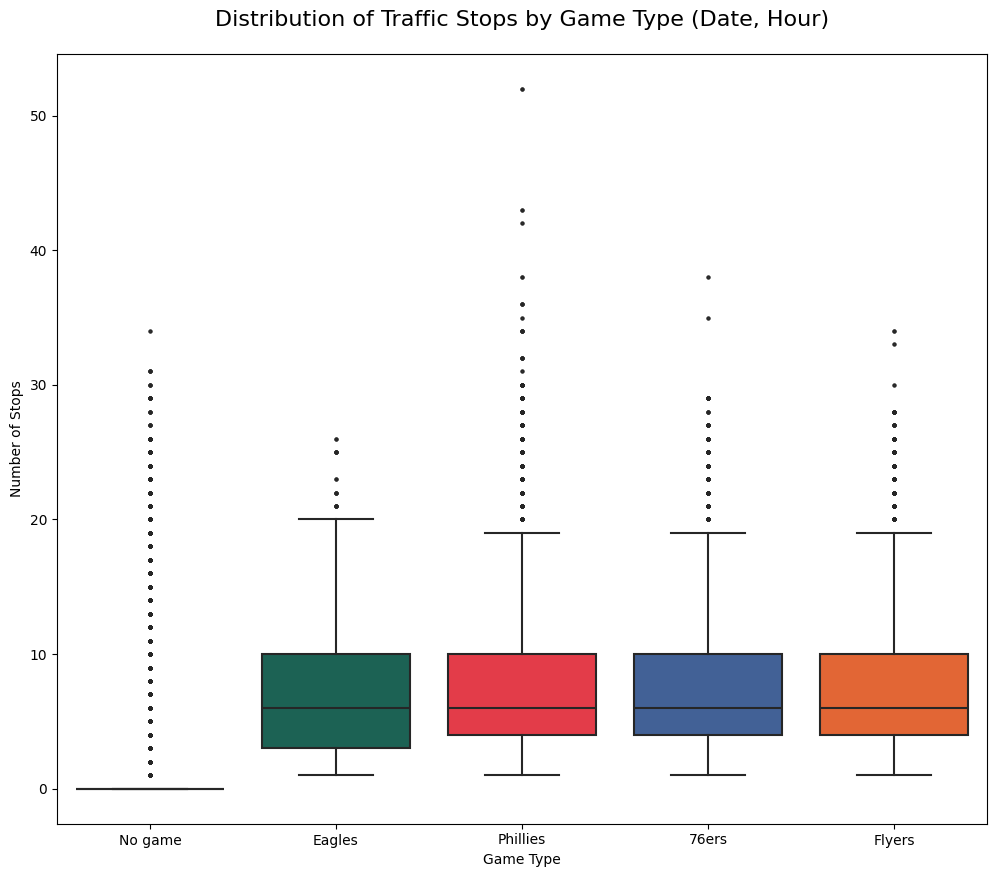

In [24]:
plt.figure(figsize=(12, 10)) 

# STOPS
sns.boxplot(
    data=philly_stops_sports,
    x='gameday_type',
    y='stop_count',
    order=['No game', 'Eagles', 'Phillies', '76ers', 'Flyers'],
    palette=custom_colors,
    showfliers=True,           # show outliers
    flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.6}
)

plt.title('Distribution of Traffic Stops by Game Type (Date, Hour)', fontsize=16, pad=20)
plt.ylabel('Number of Stops')
plt.xlabel('Game Type')
# plt.xticks(rotation=15, ha='right')

In [25]:
summary = philly_stops_sports.groupby('gameday_type')['stop_count'].describe()
summary

,count,mean,std,min,25%,50%,75%,max
gameday_type,,,,,,,,
76ers,16821.0,7.308127,4.983218,1.0,4.0,6.0,10.0,38.0
Eagles,3025.0,6.802314,4.556733,1.0,3.0,6.0,10.0,26.0
Flyers,10437.0,7.564051,5.126424,1.0,4.0,6.0,10.0,34.0
No game,123435.0,0.874282,2.894756,0.0,0.0,0.0,0.0,34.0
Phillies,32642.0,7.497702,5.130945,1.0,4.0,6.0,10.0,52.0


The overlap might be why all the sports are so close together. Wondering if I make it so that all the boxplots are based on if it is ONLY a given sport.

In [26]:
def get_pure_game_type(row):
    eagles = row.get('eagles_home_game', 0) or row.get('eagles_away_game', 0)
    phillies = row.get('phillies_home_game', 0) or row.get('phillies_away_game', 0)
    sixers = row.get('76ers_home_game', 0) or row.get('76ers_away_game', 0)
    flyers = row.get('flyers_home_game', 0) or row.get('flyers_away_game', 0)
    
    game_count = eagles + phillies + sixers + flyers
    
    if game_count == 0:
        return 'No game'
    elif game_count > 1:
        return 'Multiple games'
    elif eagles == 1:
        return 'Eagles only'
    elif phillies == 1:
        return 'Phillies only'
    elif sixers == 1:
        return '76ers only'
    elif flyers == 1:
        return 'Flyers only'
    else:
        return 'No game'

philly_stops_sports['pure_gameday_type'] = philly_stops_sports.apply(get_pure_game_type, axis=1)

print(philly_stops_sports['pure_gameday_type'].value_counts())

pure_gameday_type
No game           123435
Phillies only      29719
Multiple games     10720
Flyers only        10437
76ers only         10349
Eagles only         1700
Name: count, dtype: int64


In [27]:
custom_colors = {
    'No game': '#d3d3d3',      # light gray
    'Multiple games': "#EBB685",
    'Eagles only':  '#106E5B',      # Eagles navy blue
    'Phillies only': '#FF2E3F',     # Phillies red
    '76ers only':   '#345DA4',      # 76ers blue
    'Flyers only':  '#FF5918'       # Flyers orange
}

Text(0.5, 0, 'Game Type')

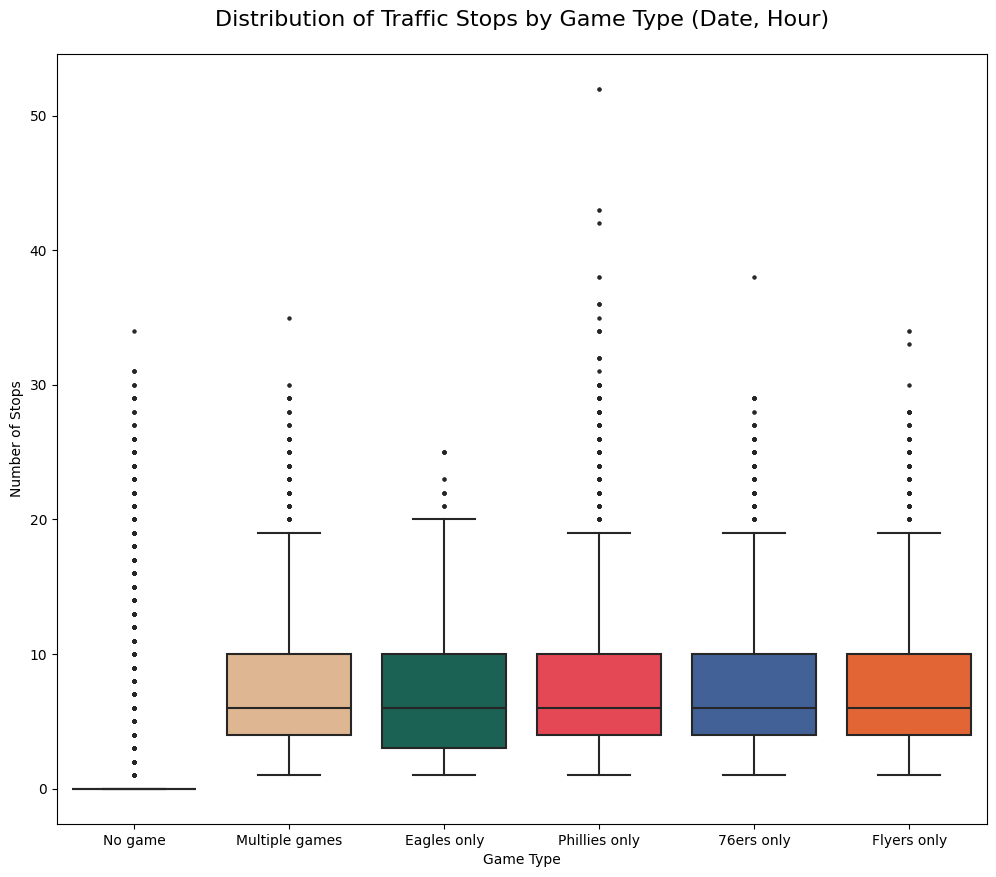

In [28]:
plt.figure(figsize=(12, 10)) 

# STOPS
sns.boxplot(
    data=philly_stops_sports,
    x='pure_gameday_type',
    y='stop_count',
    order=['No game', 'Multiple games', 'Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,
    showfliers=True,           # show outliers
    flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.6}
)

plt.title('Distribution of Traffic Stops by Game Type (Date, Hour)', fontsize=16, pad=20)
plt.ylabel('Number of Stops')
plt.xlabel('Game Type')
# plt.xticks(rotation=15, ha='right')

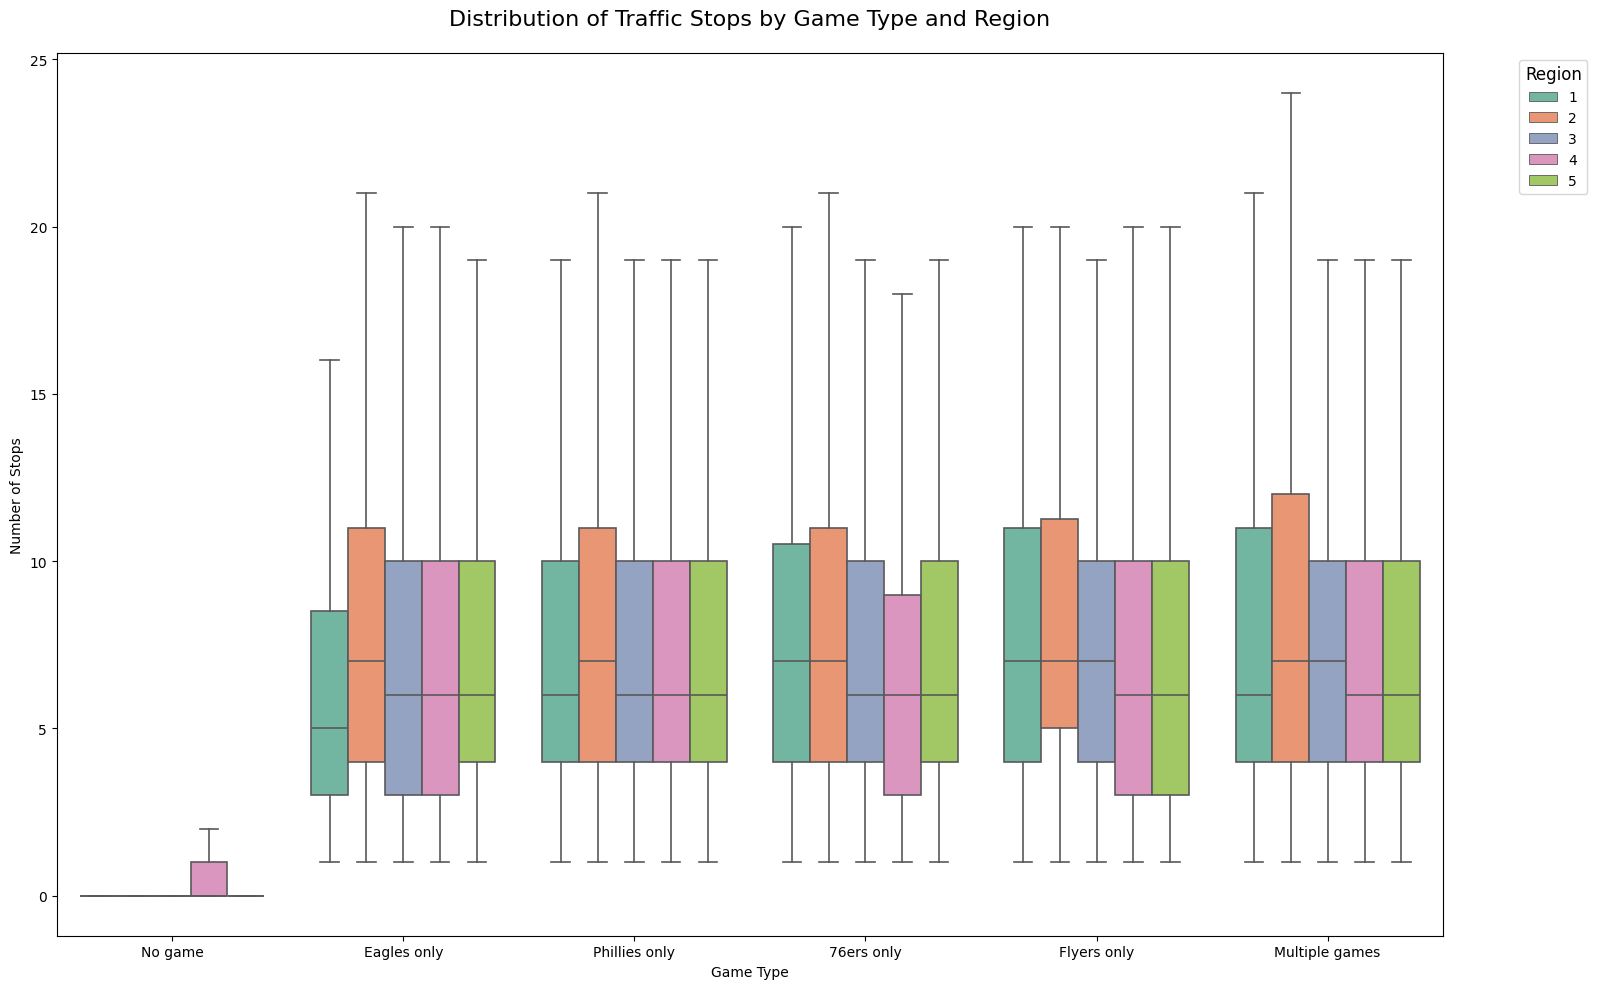

In [29]:
plt.figure(figsize=(16, 10))

sns.boxplot(
    data=philly_stops_sports,                    # your aggregated dataframe
    x='pure_gameday_type',                       # or 'gameday_type'
    y='stop_count',
    hue='region',                                # ← This creates one box per region
    order=['No game', 'Eagles only', 'Phillies only', '76ers only', 'Flyers only', 'Multiple games'],
    palette='Set2',                              # or 'tab10', 'husl', etc.
    showfliers=False,
    # flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.6},
    linewidth=1.2,
    dodge=True                                   # important: makes boxes sit side-by-side
)

plt.title('Distribution of Traffic Stops by Game Type and Region', fontsize=16, pad=20)
plt.ylabel('Number of Stops')
plt.xlabel('Game Type')
# plt.xticks(rotation=15, ha='right')
# plt.yscale('log')                                # strongly recommended

plt.legend(title='Region', title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
philly_stops_sports.groupby('pure_gameday_type')['stop_count'].describe()

,count,mean,std,min,25%,50%,75%,max
pure_gameday_type,,,,,,,,
76ers only,10349.0,7.154025,4.846050,1.0,4.0,6.0,10.0,38.0
Eagles only,1700.0,7.108824,4.687458,1.0,3.0,6.0,10.0,25.0
Flyers only,10437.0,7.564051,5.126424,1.0,4.0,6.0,10.0,34.0
Multiple games,10720.0,7.654944,5.183566,1.0,4.0,6.0,10.0,35.0
No game,123435.0,0.874282,2.894756,0.0,0.0,0.0,0.0,34.0
Phillies only,29719.0,7.404825,5.095186,1.0,4.0,6.0,10.0,52.0


Note the above two plots are number of stops and not stop density. The regions are different sizes. 

Text(0.5, 0, 'Game Type')

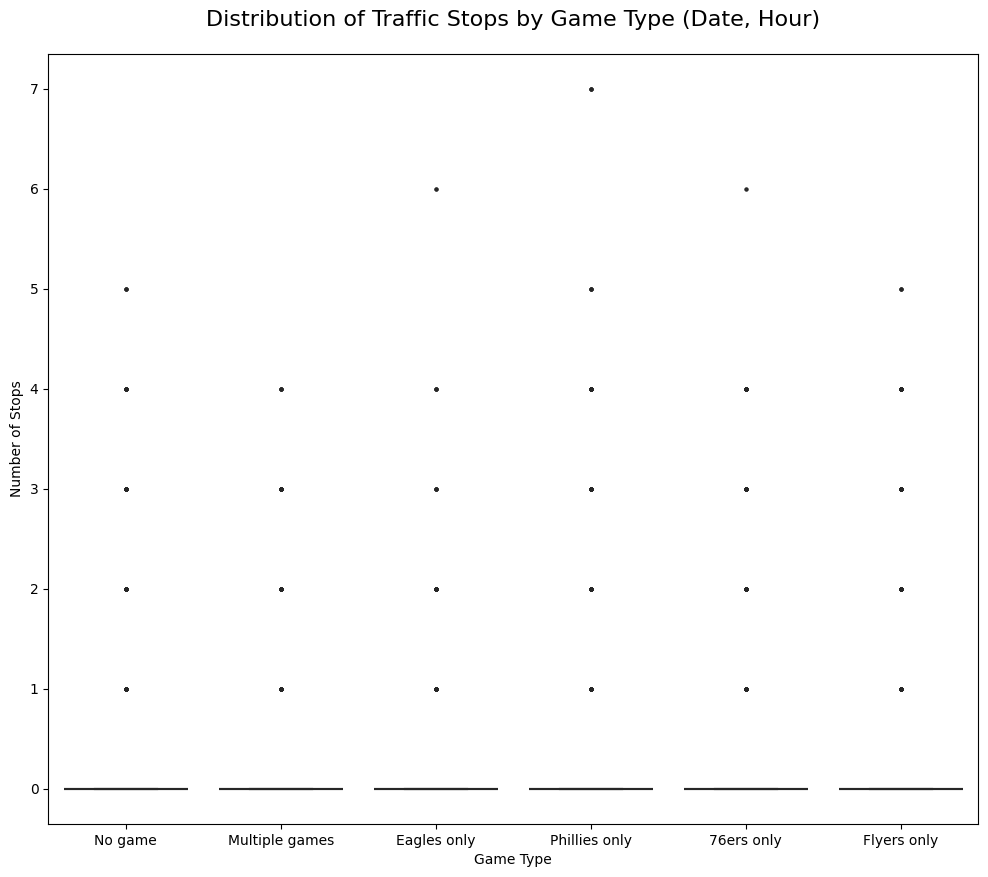

In [31]:
plt.figure(figsize=(12, 10)) 

# STOPS
sns.boxplot(
    data=philly_stops_sports,
    x='pure_gameday_type',
    y='arrest_count',
    order=['No game', 'Multiple games', 'Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,
    showfliers=True,           # show outliers
    flierprops={'marker': '.', 'markersize': 4, 'alpha': 0.6}
)

plt.title('Distribution of Traffic Stops by Game Type (Date, Hour)', fontsize=16, pad=20)
plt.ylabel('Number of Stops')
plt.xlabel('Game Type')
# plt.xticks(rotation=15, ha='right')

In [32]:
philly_stops_sports.groupby('pure_gameday_type')['arrest_count'].describe()

,count,mean,std,min,25%,50%,75%,max
pure_gameday_type,,,,,,,,
76ers only,10349.0,0.252971,0.565716,0.0,0.0,0.0,0.0,6.0
Eagles only,1700.0,0.245882,0.636917,0.0,0.0,0.0,0.0,6.0
Flyers only,10437.0,0.288780,0.596850,0.0,0.0,0.0,0.0,5.0
Multiple games,10720.0,0.270989,0.567307,0.0,0.0,0.0,0.0,4.0
No game,123435.0,0.033726,0.220081,0.0,0.0,0.0,0.0,5.0
Phillies only,29719.0,0.315287,0.626000,0.0,0.0,0.0,0.0,7.0


In [33]:
philly_stops['pure_gameday_type'] = philly_stops.apply(get_pure_game_type, axis=1)

In [34]:
df_agg = (
    philly_stops
    .groupby(['date', 'hour', 'pure_gameday_type'], as_index=False)   # adjust grouping as needed
    .agg(
        stop_count=('date', 'size'),
        arrest_count=('arrest_made', 'sum'),                    
        contraband_count=('contraband_found', 'sum')       
    )
)

df_agg['arrest_rate'] = (df_agg['arrest_count'] / df_agg['stop_count']) * 100
df_agg['contraband_rate'] = (df_agg['contraband_count'] / df_agg['stop_count']) * 100

In [35]:
df_agg

,date,hour,pure_gameday_type,stop_count,arrest_count,contraband_count,arrest_rate,contraband_rate
0,2014-01-04,20,Multiple games,1,0,0,0.0,0.0
1,2014-01-08,10,Flyers only,1,0,0,0.0,0.0
2,2014-01-08,22,Flyers only,1,0,0,0.0,0.0
3,2014-01-13,9,No game,2,0,0,0.0,0.0
4,2014-01-13,11,No game,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...
32452,2018-04-14,17,Phillies only,8,0,0,0.0,0.0
32453,2018-04-14,18,Phillies only,11,0,0,0.0,0.0
32454,2018-04-14,19,Phillies only,18,0,0,0.0,0.0
32455,2018-04-14,20,Phillies only,11,0,0,0.0,0.0


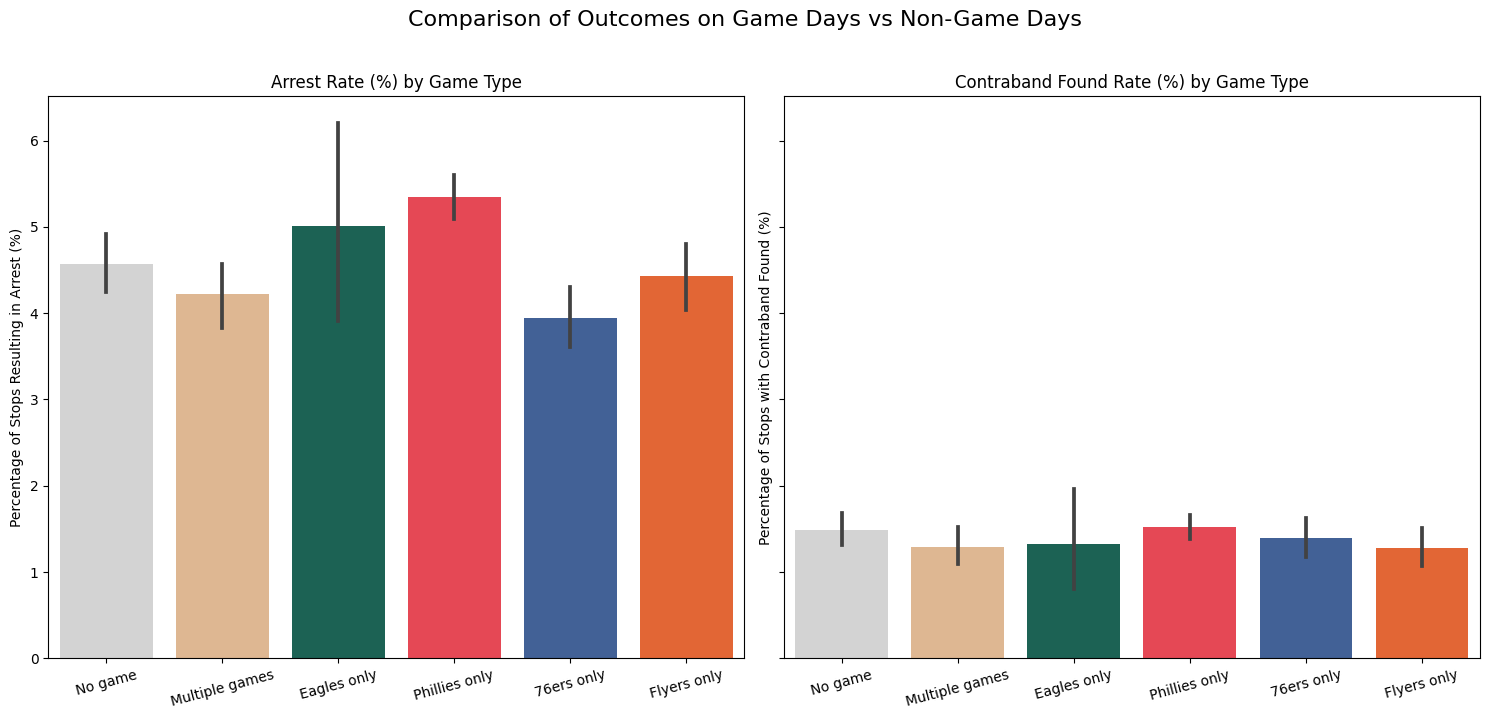

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Arrest Rate
sns.barplot(
    data=df_agg,
    x='pure_gameday_type',
    y='arrest_rate',
    ax=axes[0],
    order=['No game', 'Multiple games', 'Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,
    errorbar=('ci', 95)          # shows 95% confidence interval
)
axes[0].set_title('Arrest Rate (%) by Game Type')
axes[0].set_ylabel('Percentage of Stops Resulting in Arrest (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Contraband Rate
sns.barplot(
    data=df_agg,
    x='pure_gameday_type',
    y='contraband_rate',
    ax=axes[1],
    order=['No game', 'Multiple games', 'Eagles only', 'Phillies only', '76ers only', 'Flyers only'],
    palette=custom_colors,
    errorbar=('ci', 95)
)
axes[1].set_title('Contraband Found Rate (%) by Game Type')
axes[1].set_ylabel('Percentage of Stops with Contraband Found (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparison of Outcomes on Game Days vs Non-Game Days', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [37]:

df_agg['date'] = pd.to_datetime(df_agg['date'])

df_agg['year'] = df_agg['date'].dt.year
df_agg['month'] = df_agg['date'].dt.month
df_agg['day_of_week'] = df_agg['date'].dt.day_name()
df_agg['hour'] = df_agg['hour']          # assuming you have this column
df_agg['week_of_year'] = df_agg['date'].dt.isocalendar().week

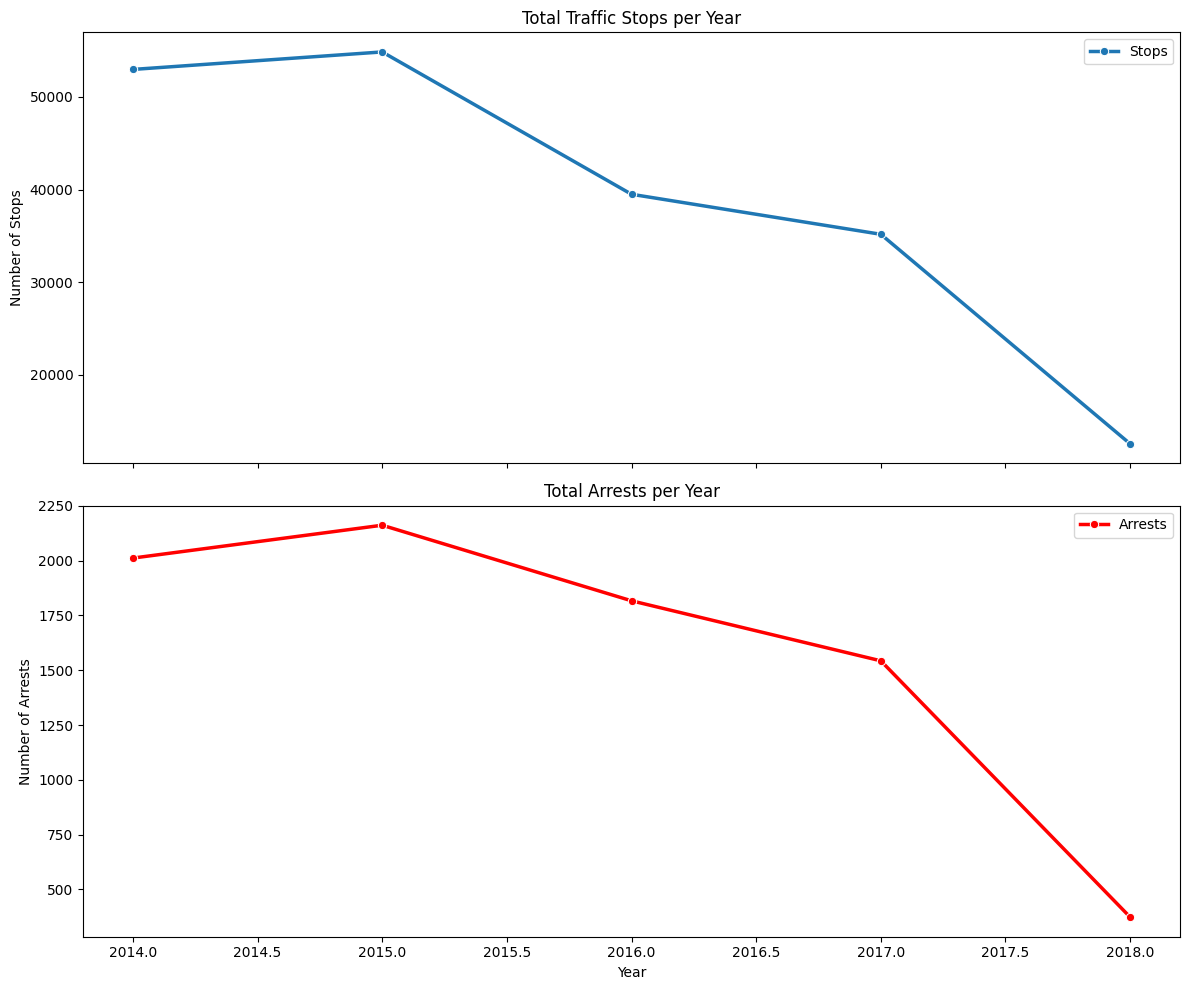

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Stops by Year
sns.lineplot(
    data=df_agg.groupby('year').agg({'stop_count': 'sum', 'arrest_count': 'sum'}).reset_index(),
    x='year',
    y='stop_count',
    ax=axes[0],
    marker='o',
    linewidth=2.5,
    label='Stops'
)
axes[0].set_title('Total Traffic Stops per Year')
axes[0].set_ylabel('Number of Stops')

# Arrests by Year
sns.lineplot(
    data=df_agg.groupby('year').agg({'stop_count': 'sum', 'arrest_count': 'sum'}).reset_index(),
    x='year',
    y='arrest_count',
    ax=axes[1],
    marker='o',
    linewidth=2.5,
    color='red',
    label='Arrests'
)
axes[1].set_title('Total Arrests per Year')
axes[1].set_ylabel('Number of Arrests')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

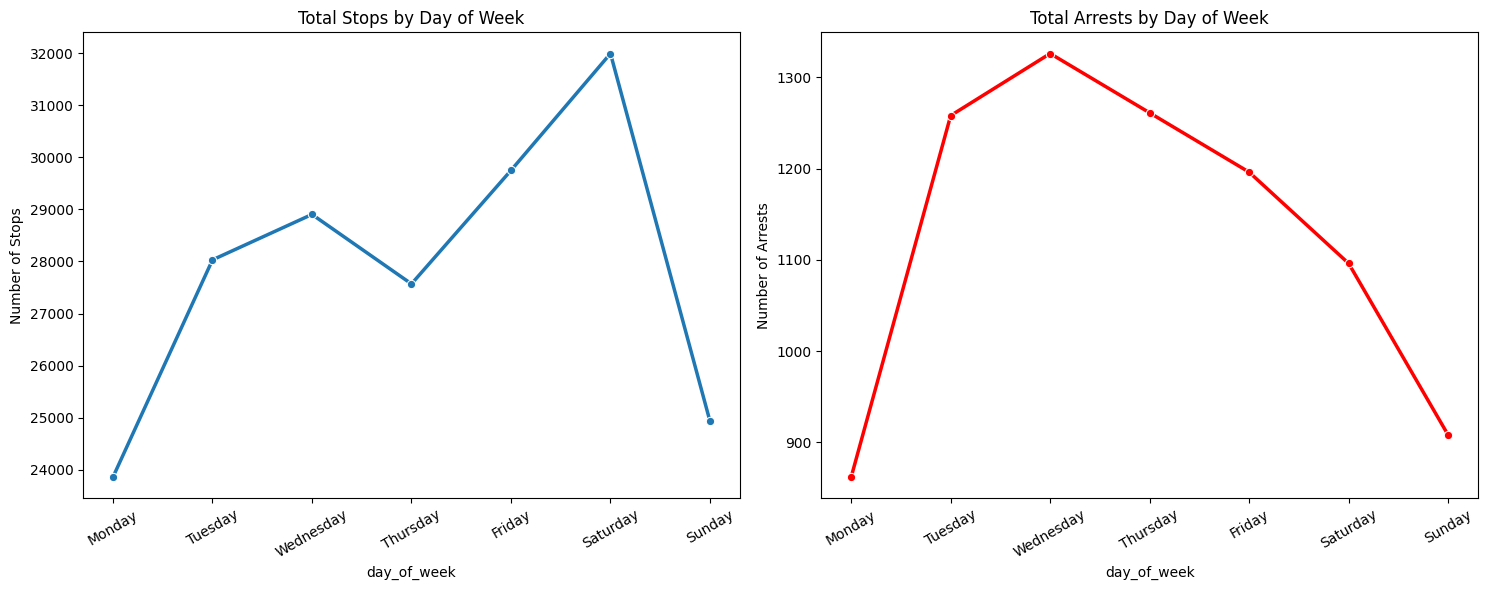

In [39]:
# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily = df_agg.groupby('day_of_week').agg({
    'stop_count': 'sum',
    'arrest_count': 'sum'
}).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.lineplot(data=daily, x='day_of_week', y='stop_count', ax=axes[0], marker='o', linewidth=2.5)
axes[0].set_title('Total Stops by Day of Week')
axes[0].set_ylabel('Number of Stops')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(data=daily, x='day_of_week', y='arrest_count', ax=axes[1], marker='o', linewidth=2.5, color='red')
axes[1].set_title('Total Arrests by Day of Week')
axes[1].set_ylabel('Number of Arrests')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

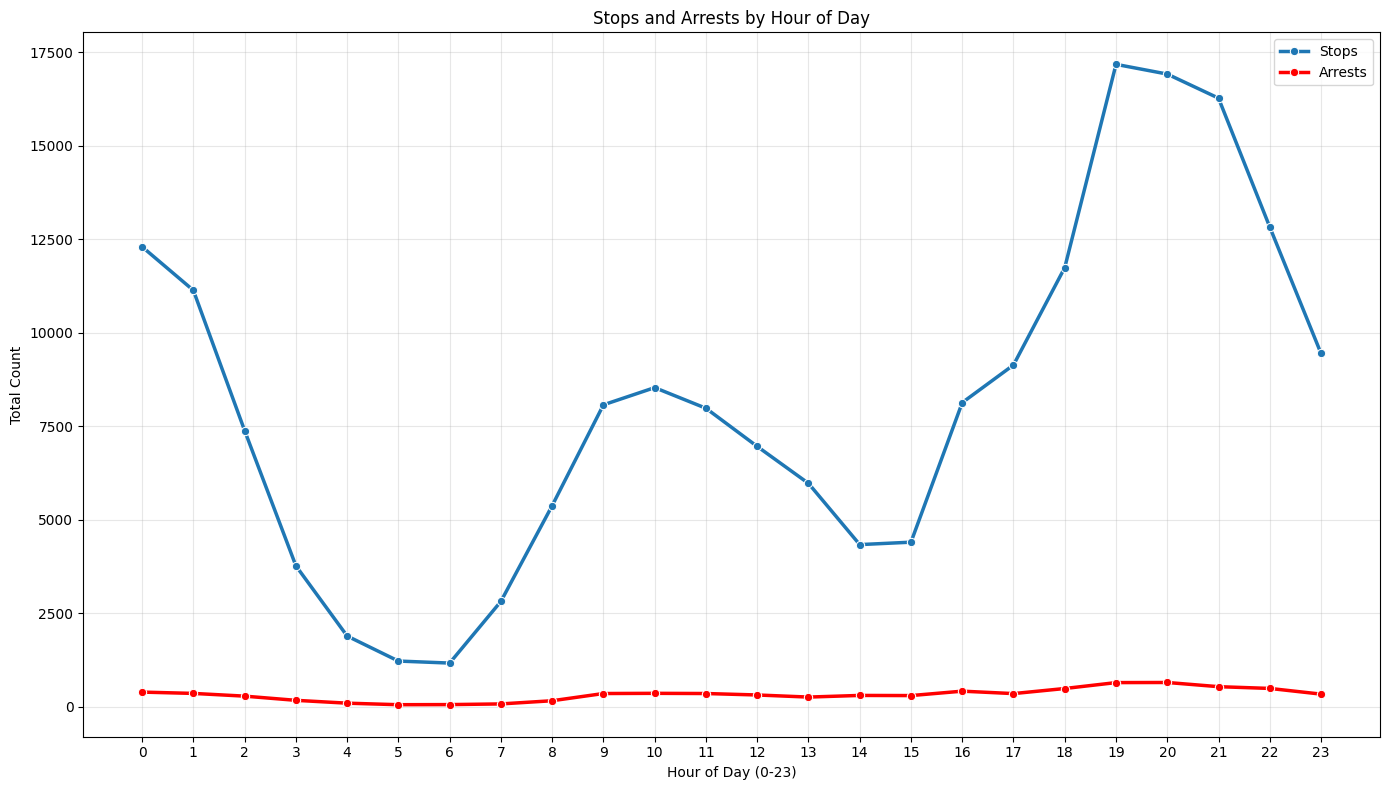

In [40]:
hourly = df_agg.groupby('hour').agg({
    'stop_count': 'sum',
    'arrest_count': 'sum'
}).reset_index()

plt.figure(figsize=(14, 8))

sns.lineplot(data=hourly, x='hour', y='stop_count', marker='o', linewidth=2.5, label='Stops')
sns.lineplot(data=hourly, x='hour', y='arrest_count', marker='o', linewidth=2.5, color='red', label='Arrests')

plt.title('Stops and Arrests by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Total Count')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

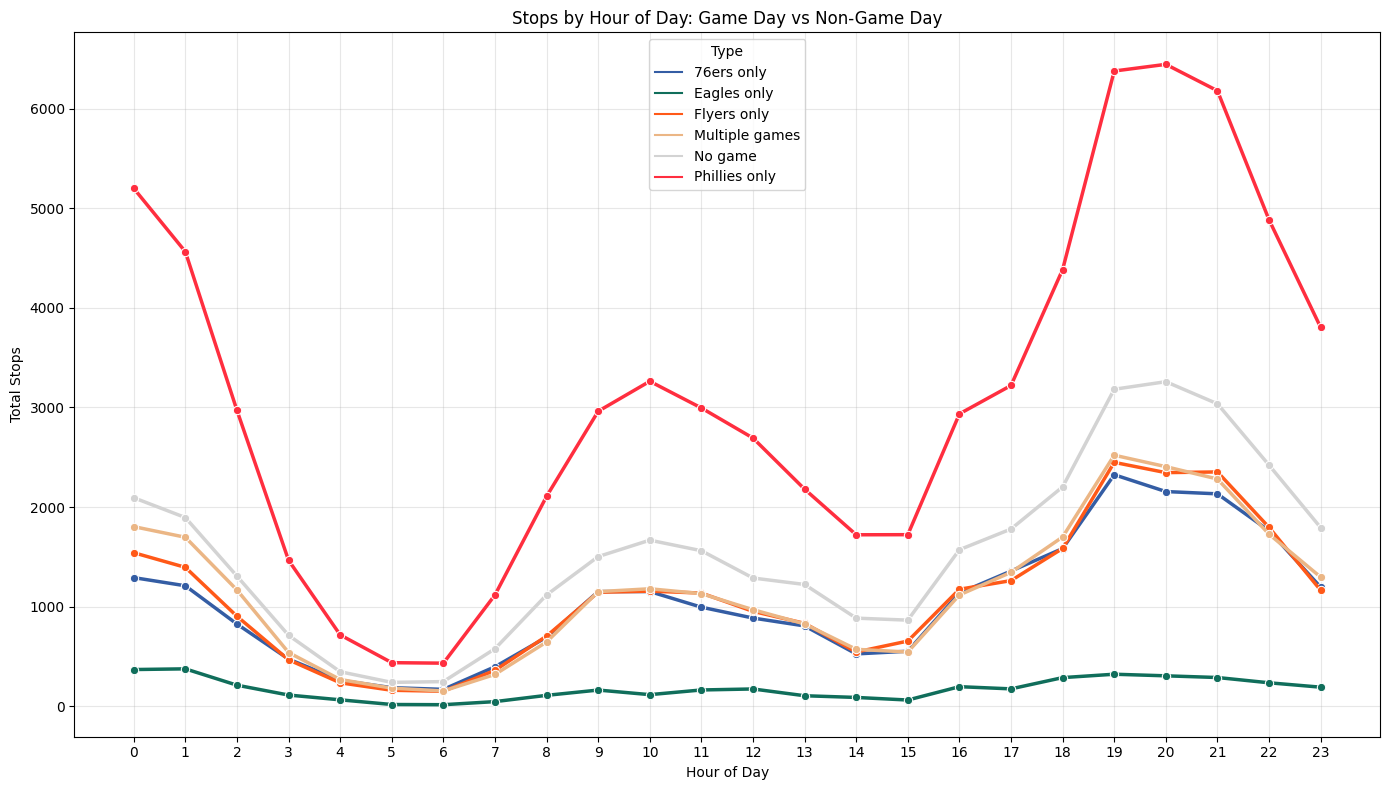

In [41]:
# Group by hour + GameDay
hourly_game = df_agg.groupby(['hour', 'pure_gameday_type']).agg({
    'stop_count': 'sum',
    'arrest_count': 'sum'
}).reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=hourly_game,
    x='hour',
    y='stop_count',
    hue='pure_gameday_type',
    palette=custom_colors,
    marker='o',
    linewidth=2.5
)
plt.title('Stops by Hour of Day: Game Day vs Non-Game Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Stops')
plt.xticks(range(0, 24))
plt.legend(title='Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
df_agg

,date,hour,pure_gameday_type,stop_count,arrest_count,contraband_count,arrest_rate,contraband_rate,year,month,day_of_week,week_of_year
0,2014-01-04,20,Multiple games,1,0,0,0.0,0.0,2014,1,Saturday,1
1,2014-01-08,10,Flyers only,1,0,0,0.0,0.0,2014,1,Wednesday,2
2,2014-01-08,22,Flyers only,1,0,0,0.0,0.0,2014,1,Wednesday,2
3,2014-01-13,9,No game,2,0,0,0.0,0.0,2014,1,Monday,3
4,2014-01-13,11,No game,1,0,0,0.0,0.0,2014,1,Monday,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32452,2018-04-14,17,Phillies only,8,0,0,0.0,0.0,2018,4,Saturday,15
32453,2018-04-14,18,Phillies only,11,0,0,0.0,0.0,2018,4,Saturday,15
32454,2018-04-14,19,Phillies only,18,0,0,0.0,0.0,2018,4,Saturday,15
32455,2018-04-14,20,Phillies only,11,0,0,0.0,0.0,2018,4,Saturday,15


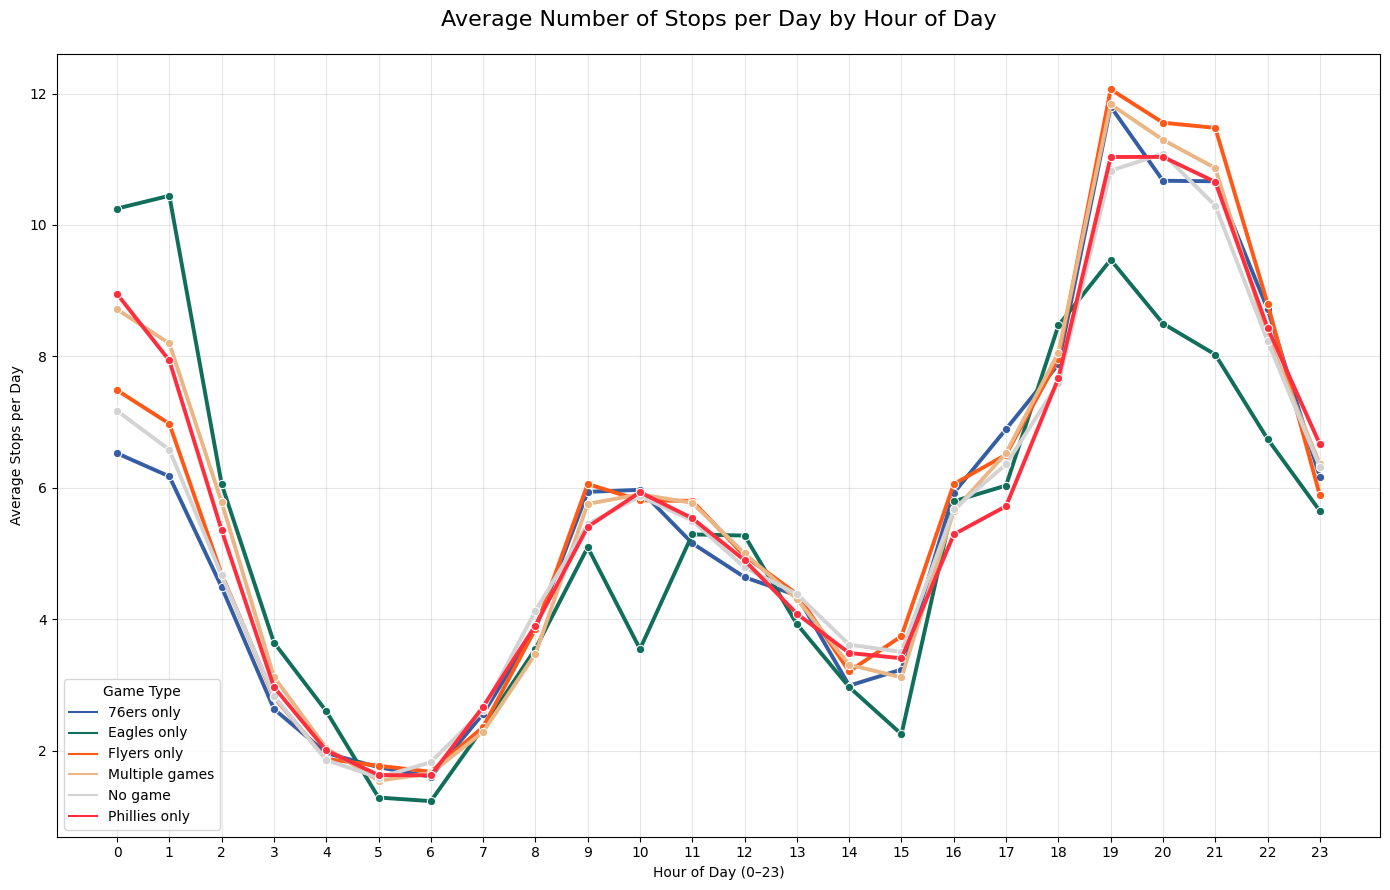

In [47]:
hourly_avg = (
    df_agg
    .groupby(['hour', 'pure_gameday_type'])
    .agg(
        total_stops=('stop_count', 'sum'),
        total_arrests=('arrest_count', 'sum'),
        num_days=('date', 'nunique')        # ← crucial: count unique days
    )
    .reset_index()
)

hourly_avg['avg_stops_per_day'] = hourly_avg['total_stops'] / hourly_avg['num_days']
hourly_avg['avg_arrests_per_day'] = hourly_avg['total_arrests'] / hourly_avg['num_days']

plt.figure(figsize=(14, 9))

sns.lineplot(
    data=hourly_avg,
    x='hour',
    y='avg_stops_per_day',
    hue='pure_gameday_type',
    palette=custom_colors,          # use your custom colors if defined
    marker='o',
    linewidth=2.8,
    markersize=6
)

plt.title('Average Number of Stops per Day by Hour of Day', fontsize=16, pad=20)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Average Stops per Day')
plt.xticks(range(0, 24))
plt.legend(title='Game Type')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
philly_stops.columns

Index(['raw_row_number', 'date', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband',
       'eagles_home_game', 'eagles_away_game', '76ers_home_game',
       '76ers_away_game', 'phillies_home_game', 'phillies_away_game',
       'flyers_home_game', 'flyers_away_game', 'distance_from_eagles',
       'distance_from_76ers', 'distance_from_phillies', 'distance_from_flyers',
       'distance_from_eagles_km', 'distance_from_76ers_km',
       'distance_from_phillies_km', 'distance_from_flyers_km', 'distance_km',
       'region', 'hour', 'pure_gameday_type'],
      dtype='object')